In [1]:

import numpy as np
import random
import itertools
import pandas as pd
import os
import networkx as nx
from scipy.sparse import csr_matrix
from copy import copy
import ot
from EDRep_main.EDRep import NodeEmbedding  
import glob 
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import scipy.spatial.distance as ssd
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.decomposition import NMF
import seaborn as sns
import numpy as np
from scipy.spatial.distance import squareform
from sklearn.metrics.cluster import normalized_mutual_info_score as NMI


# from joblib import Parallel, delayed

In [25]:
def generateSequence(outputfolder, model, args, n_graphs, verbose = True, append_name = '.csv'):
    '''This function generates a sequence of graphs that have a common generative model in each block
    
    Use: generateSequence(outputfolder, model, args, n_graphs)
    
    Inputs: 
        * outputfolder : directory to which the files will be saved
        * model (function): function of the generative model to be considered
        * args (list of lists): arguments of model
        * n_graphs (int): number of graphs to be generated

    Optional inputs:
        * verbose (boolean): if True (default) prints the progress bar
        * append_name (string): what goes at the end of the file name. Can be used to change the extension or also part of the name of the file. By default `.csv`
        
    Outputs:
        * this function will output the edgelist representation of the generated graphs numbered in ascending order.       
    '''
    
    for i in range(n_graphs):
            
        df = model(args)
        df.to_csv(outputfolder + '/EL' + str(i+1) + append_name, index = False)

        # print progress bar
        if verbose == 1:
            print("[%-25s] %d%%" % ('='*(int(i/(n_graphs)*25)) + '>', (i+1)/(n_graphs)*100), end = '\r')
        
    return

In [26]:
def DCSBM(args):
    ''' 
    Function that generates a graph from the degree-corrected stochastic block model with
    n nodes and k communities
    
    Note that, with an appropriate choice of the parameters, this function can be used to
    generate an SBM or and ER random graph
    
    Use:
        edge_list = DCSBM(C,c, ℓ, θ, symmetric, make_connected)
    Inputs:
        args = C, c, ℓ, θ
            * C (array of size k x k) : affinity matrix of the network C
            * c (scalar) : average degree of the network
            * ℓ (array of size n) : vector containing the label of each node
            * θ  (array of size n) : vector with the intrinsic probability connection of each node
            * symmetric (bool): if True it returns an undirected graph
            * make_connected (bool): if True forces the graph to be connected adding edges
    
    Outputs:
        * edge_list (pandas dataframe) : edge list representation of the graph (ij)
        
    '''
    
    C, c, ℓ, θ, symmetric, make_connected  = args

    # number of communities
    k = len(np.unique(ℓ))
    
    # number of nodes
    n = len(θ)
    
    # (k x n) matrix where we store the value of the affinity wrt a given label for each node
    c_v = C[ℓ].T
    
    fs = list()
    ss = list()

    # we choose the nodes that should get connected wp = θ_i/n
    if symmetric:
        first = np.random.choice(n,int(n*c/2),p = θ/n)

    else:  
        first = np.random.choice(n,int(n*c),p = θ/n) 

    for i in range(k): 
        v = θ*c_v[i]
        
        # among the nodes of first, select those with label i
        first_selected = first[ℓ[first] == i]
        fs.append(first_selected.tolist())
        
        # choose the nodes to connect to the first_selected
        second_selected = np.random.choice(n,len(first_selected), p = v/np.sum(v))
        ss.append(second_selected.tolist())

    fs = list(itertools.chain(*fs))
    ss = list(itertools.chain(*ss))

    fs = np.array(fs)
    ss  = np.array(ss)


    # add nodes not appearing in the vector first, to ensure the graph is connected
    if make_connected:
        idx = np.arange(n)[np.logical_not(np.isin(np.arange(n), fs))]
        fs = np.concatenate([fs, idx])
        ss = np.concatenate([ss, np.argmax(θ)*np.ones(len(idx))])
    

    # create the edge list from the connection defined earlier
    edge_list = np.column_stack((fs,ss)) 
    
    # remove edges appearing more then once
    edge_list = np.unique(edge_list, axis = 0) 

    # replace self edges
    idx = edge_list[:,0] == edge_list[:,1]
    edge_list[:,1][idx] += 1
    idx = edge_list[:,1] == n
    edge_list[:,1][idx] = 0

    if symmetric:
        df = pd.DataFrame(columns = ['i', 'j'])
        M = np.maximum(edge_list[:,0], edge_list[:,1])
        m = np.minimum(edge_list[:,0], edge_list[:,1])
        df.i = np.concatenate([M, m])
        df.j = np.concatenate([m, M])

    else:
        df = pd.DataFrame(columns = ['i', 'j'])
        df.i = edge_list[:,0]
        df.j = edge_list[:,1]

    # add an edge to nodes with degree 0
    A = csr_matrix((np.ones(len(df)), (df.i, df.j)), shape = (n,n))
    d = A@np.ones(n)
    idx = d == 0


    return df


In [27]:
def GeometricModel(args):
    '''Generates an instance of a modified Geometric model from a given configuration of the points in space
    
    Use: A = GeometricModel(X, d, β)
    
    Inputs: args
        * X (array): coordinates of the points used to form edges
        * d (float): average degree
        * β (float): noise parameter
        
    Ouptput:
        * A (sparse csr_matrix): adjacency matrix of the generated graph'''


    X, d, β = args
    n = np.shape(X)[0]

    # compute the pairwise distance matrix
    no = (X**2)@np.ones(2)
    D = np.zeros((n,n))
    for i in range(n):
        D[i] += no
        D[:,i] += no

    D -= 2*X@X.T
    D = np.sqrt(np.abs(D))

    # compute the probability matrix
    P = np.exp(-β*D)
    P = P - np.diag(np.diag(P))
    p = P@np.ones(n)
    P = np.diag(p**(-1)).dot(P)
    
    # draw the edges
    idx1 = np.concatenate([np.ones(int(d/2))*i for i in range(n)])
    idx2 = np.concatenate([np.random.choice(np.arange(n), int(d/2), p = P[i], replace = False) for i in range(n)])

    df = pd.DataFrame(columns = ['i', 'j'])

    # symmetrize
    df.i = np.concatenate([idx1, idx2])
    df.j = np.concatenate([idx2, idx1])

    return df


In [ ]:
def EmbDistance(X, Y, distance_type = 'unmatched'):
    '''This function computes the distance between 

    Use: d = EmbDistance(X, Y)

    Inputs:
        * X, Y (arrays): input embeddings corresponding to the two temporal graphs. The number of rows of the two matrices must be the same.
        
    Optional inputs:
        * distance_type (string): can be 'unmatched' or 'matched'

    Output:
        * d (float): distance between the two graphs.
    '''

    n1, d1 = X.shape
    n2, d2 = Y.shape

    # run initial checks

    if d1 != d2:
        raise DeprecationWarning('The embedding matrices have different dimensions')
    else:
        d = d1

    
    if distance_type not in ['unmatched', 'matched']:
        raise DeprecationWarning('The distance type is not valid')
    
    else:
        if (distance_type == 'matched') and (n1 != n2):
            raise DeprecationWarning("The input matrices do not have the same size")
        else:
            n = n1

    if distance_type == 'matched':
        Mxx = X.T@X
        Mxy = X.T@Y
        Myy = Y.T@Y
        d = np.sqrt(np.abs(np.linalg.norm(Mxx)**2 + np.linalg.norm(Myy)**2 - 2*np.linalg.norm(Mxy)**2))

    else:
        n1, n2 = X.shape[0], Y.shape[0]
        λ1 = np.linalg.eigvalsh(X.T@X)/n1
        λ2 = np.linalg.eigvalsh(Y.T@Y)/n2
        d = np.linalg.norm(λ1-λ2)
  
    return d

DCSBM: Nodes are partitioned into distinct groups and connection probabilities depend on their respective group memberships.

In [109]:
output_folder_dcsbm = r"C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_dcsbm"
os.makedirs(output_folder_dcsbm, exist_ok=True)

In [110]:
n_dcsbm = 1000  
k_dcsbm = 5
c_in = 25
c_out = 1

C_dcsbm = np.ones((k_dcsbm,k_dcsbm)) * c_out
C_dcsbm += np.diag(np.ones(k_dcsbm)) * (c_in - c_out)
c_dcsbm = (c_in + (k_dcsbm-1)*c_out) / k_dcsbm

symmetric = True
make_connected = True

θ_dcsbm = np.ones(n_dcsbm)
ℓ_dcsbm = np.zeros(n_dcsbm)
for i in range(k_dcsbm):
    ℓ_dcsbm[i*int(n_dcsbm/k_dcsbm): (i+1)*int(n_dcsbm/k_dcsbm)] = i
ℓ_dcsbm = ℓ_dcsbm.astype(int)

args_dcsbm = (C_dcsbm, c_dcsbm, ℓ_dcsbm, θ_dcsbm, symmetric, make_connected)


generateSequence(
    outputfolder=output_folder_dcsbm, 
    model=DCSBM,             
    args=args_dcsbm,         
    n_graphs=20,             
    verbose=True             
)


ER: Nodes are connected by chance, where every possible pair has an independent and equal probability of forming an edge. It creates a highly homogeneous network lacking distinct hubs or communities.

In [113]:
output_folder_er= r"C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_er"
os.makedirs(output_folder_er, exist_ok=True)

In [114]:
## ER
n0_er= 1000
γ = 0.8
k_er = 1
c_er= (c_in + (k_er-1)*c_out)/k_er
C_er = np.ones((k_er,k_er))*c_er
c_er= (c_in + (k_er-1)*c_out)/k_er
    
n_er= np.random.randint(int(n0_er*(1-γ)), int(n0_er*(1+γ)))
ℓ_er= np.zeros(n_er).astype(int)
θ_er = np.ones(n_er)
args_er = (C_er, c_er, ℓ_er, θ_er, symmetric, make_connected)


 
generateSequence(
    outputfolder=output_folder_er, 
    model=DCSBM,             
    args=args_er,         
    n_graphs=20,             
    verbose=True             
)

CM: This model generates a random graph by randomly pairing "half-edges" to enforce a predefined degree sequence. It allows for the creation of scale-free networks.

In [117]:
output_folder_conf= r"C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration"
os.makedirs(output_folder_conf, exist_ok=True)

In [118]:
### Configuration model
n0_conf=1000
γ = 0.8
n_conf = np.random.randint(int(n0_conf*(1-γ)), int(n0_conf*(1+γ)))
θ_conf = np.random.uniform(3,10, n_conf)**4
θ_conf = θ_conf/np.mean(θ_conf)
ℓ_conf = np.zeros(n_conf).astype(int)
args_conf = (C_er, c_er, ℓ_conf, θ_conf, symmetric, make_connected)

generateSequence(
    outputfolder=output_folder_conf, 
    model=DCSBM,             
    args=args_conf,         
    n_graphs=20,             
    verbose=True             
)
  

GM: Nodes are randomly distributed in a spatial domain and edges are formed exclusively between nodes that fall within a specific physical distance threshold. It naturally captures spatial proximity and high local clustering.

In [119]:
output_folder_geo= r"C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_geo"
os.makedirs(output_folder_geo, exist_ok=True)

In [120]:
### Geometric model
β = 20
γ = 0.8
n0_geo=1000
n_geo = np.random.randint(int(n0_geo*(1-γ)), int(n0_geo*(1+γ)))

r_geo = np.random.uniform(0, 1, n_geo)
θ_geo = np.random.uniform(0, 2*np.pi, n_geo)
X = np.zeros((n_geo, 2))
X[:,0] = r_geo*np.cos(θ_geo)
X[:,1] = r_geo*np.sin(θ_geo)
args_geo= (X, c_er, β)

generateSequence(
    outputfolder=output_folder_geo, 
    model= GeometricModel,             
    args=args_geo,         
    n_graphs=20,             
    verbose=True             
)
  

In [37]:
def get_adj(filepath):
    df = pd.read_csv(filepath)
    G = nx.from_pandas_edgelist(df, 'i', 'j')
    A = nx.adjacency_matrix(G).astype(float)

    return A

In [38]:
def node_embedding(g, dim_embedding,seed=42):
    rdn_state = np.random.get_state()
    random.seed(seed)
    np.random.seed(seed)
    embedding_a = NodeEmbedding(g, dim=dim_embedding, k=1, verbose=False)
    X_total = embedding_a.X
    np.random.set_state(rdn_state)
    return X_total

In [39]:
def w2_distance(emb_1, emb_2):
    S_1=emb_1@emb_1.T
    S_2=emb_2@emb_2.T
    vals_S_1=S_1.flatten()
    vals_S_2=S_2.flatten()
    wd2 = ot.wasserstein_1d(vals_S_1, vals_S_2, p=2)**(1/2)
    return wd2

In [40]:
def create_embeddings(path_files, dim):
    embeddings = []

    for file in tqdm(path_files, desc="Calcolando embeddings"):
        a = get_adj(file)
        emb = node_embedding(a, dim)
        embeddings.append(emb)
        
    return embeddings

In [121]:
path_files_dcsbm = glob.glob(os.path.join(output_folder_dcsbm, "*.csv"))
path_files_er = glob.glob(os.path.join(output_folder_er, "*.csv"))
path_files_conf = glob.glob(os.path.join(output_folder_conf, "*.csv"))
path_files_geo = glob.glob(os.path.join(output_folder_geo, "*.csv"))

In [95]:
def distances(embeddings, n):
    old_d = []
    new_d = []
    subset = embeddings[:n]
    
    k = len(subset)

    total_iters = k * (k - 1) // 2

    for a, b in tqdm(itertools.combinations(subset, 2), total=total_iters, desc="Calcolando distanze"):
        old = EmbDistance(a, b, 'unmatched')
        new = w2_distance(a, b)
        old_d.append(old)
        new_d.append(new)
 
    return old_d, new_d


In [98]:
def comparison_plot(old_d, new_d, name):
    plt.figure(figsize=(8, 6))

    plt.scatter(old_d, new_d,alpha=0.6)

    plt.xlabel("unmatched")
    plt.ylabel("wasserstein")
    plt.title(f"Comparing distances for {name} (Similar graphs)")
    plt.grid(True)
    plt.show()

In [122]:
embeddings_dcsbm=create_embeddings(path_files_dcsbm,32)
embeddings_er=create_embeddings(path_files_er,32)
embeddings_conf=create_embeddings(path_files_conf,32)
embeddings_geo=create_embeddings(path_files_geo,32)
embedding_tot= embeddings_dcsbm + embeddings_er + embeddings_conf + embeddings_geo

Calcolando embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Calcolando embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Calcolando embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Calcolando embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Comparison of distances for DCSBM graphs

Calcolando distanze:   0%|          | 0/190 [00:00<?, ?it/s]

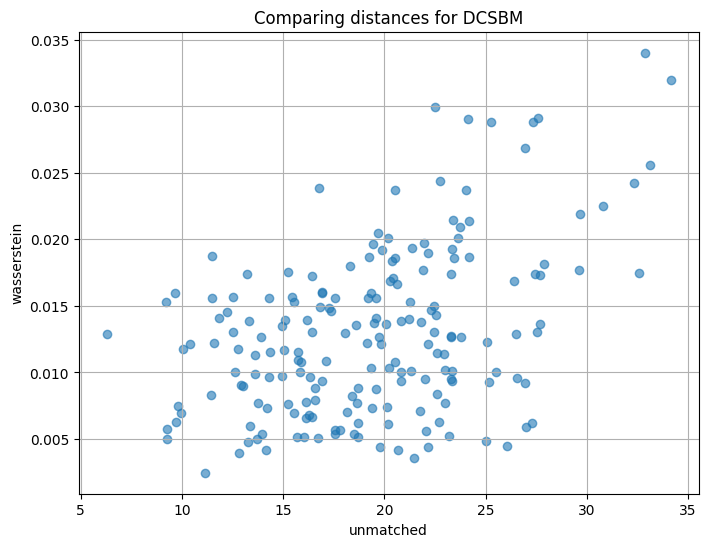

In [45]:
unmatched_old_dcsbm, unmatched_new_dcsbm = distances(embeddings_dcsbm,30)

comparison_plot(unmatched_old_dcsbm, unmatched_new_dcsbm, 'DCSBM')

Comparison of distances for ER graphs

Calcolando distanze:   0%|          | 0/190 [00:00<?, ?it/s]

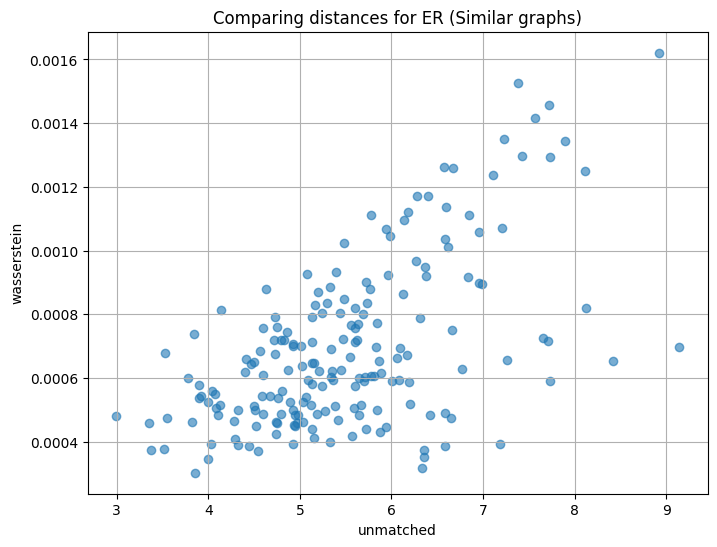

In [107]:
unmatched_old_er, unmatched_new_er = distances(embeddings_er,20)

comparison_plot(unmatched_old_er, unmatched_new_er, 'ER')

Comparison of distances for CONFIGURATION MODEL graphs

Calcolando distanze:   0%|          | 0/190 [00:00<?, ?it/s]

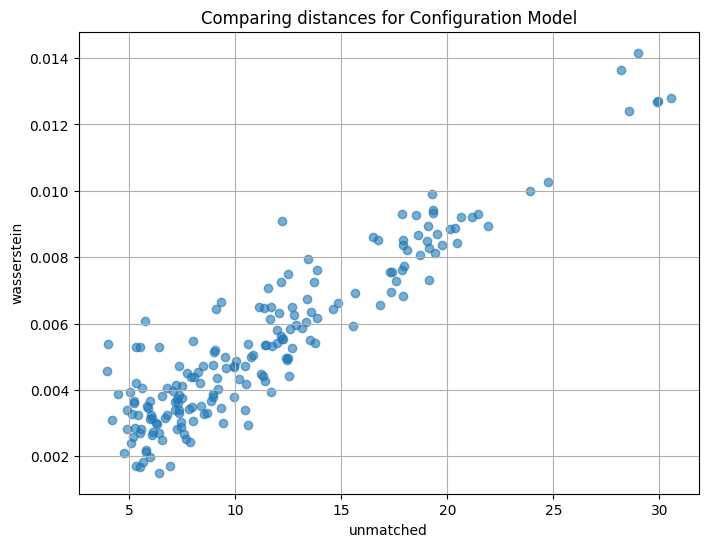

In [47]:
unmatched_old_conf, unmatched_new_conf = distances(embeddings_conf,30)

comparison_plot(unmatched_old_conf, unmatched_new_conf,'Configuration Model')

Comparison of distances for GEOMETRIC MODEL graphs

Calcolando distanze:   0%|          | 0/190 [00:00<?, ?it/s]

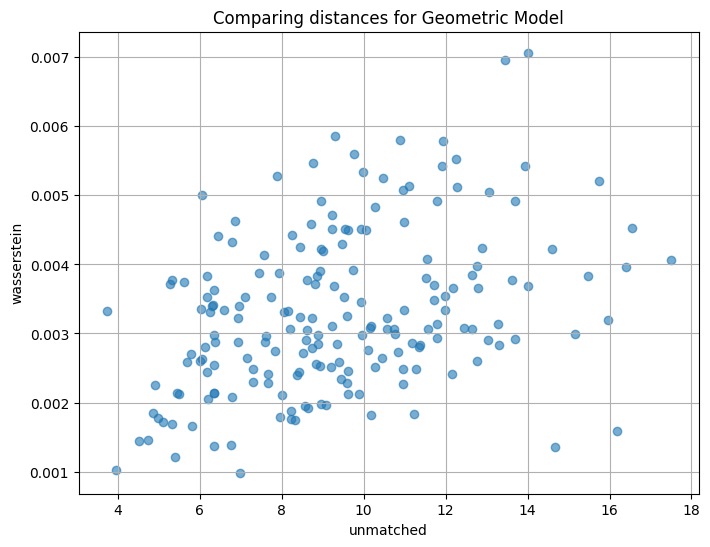

In [48]:
unmatched_old_geo, unmatched_new_geo= distances(embeddings_geo,30)

comparison_plot(unmatched_old_geo, unmatched_new_geo, 'Geometric Model')

Calcolando distanze:   0%|          | 0/3160 [00:00<?, ?it/s]

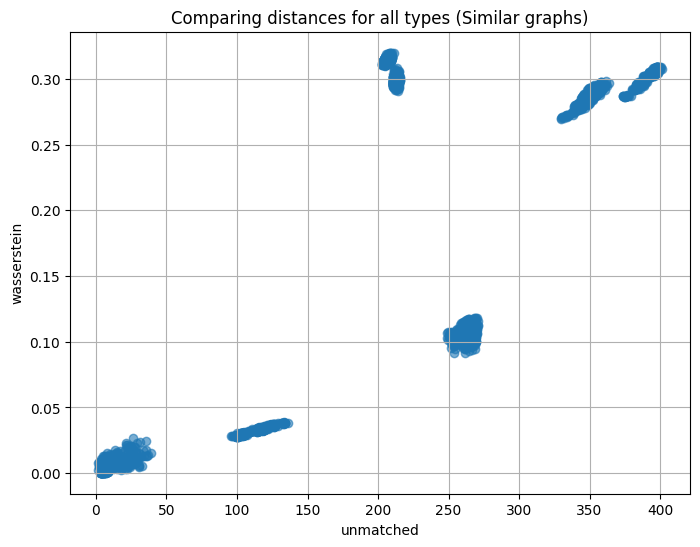

In [123]:
unmatched_old_tot, unmatched_new_tot= distances(embedding_tot,80)

comparison_plot(unmatched_old_tot, unmatched_new_tot, 'all types')

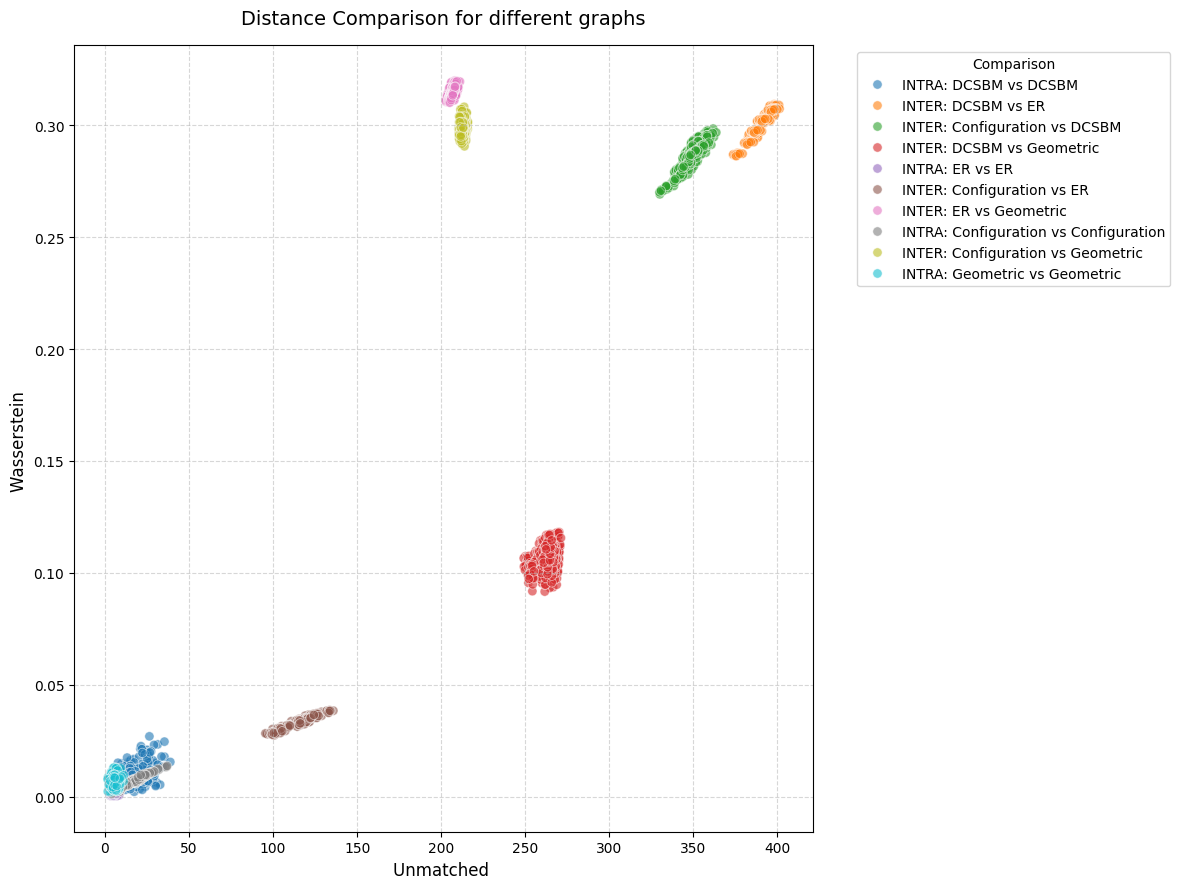

In [126]:
N = 80
labels = [0]*20 + [1]*20 + [2]*20 + [3]*20
models_name = {0: 'DCSBM', 1: 'ER', 2: 'Configuration', 3: 'Geometric'}

categories = []
for i, j in itertools.combinations(range(N), 2):
    mod_i = models_name[labels[i]]
    mod_j = models_name[labels[j]]
    
    if mod_i == mod_j:
        categories.append(f"INTRA: {mod_i} vs {mod_i}")
    else:
        ordered_models = sorted([mod_i, mod_j])
        categories.append(f"INTER: {ordered_models[0]} vs {ordered_models[1]}")

# faccio un dataframe 
df_plot = pd.DataFrame({
    'Unmatched': unmatched_old_tot,
    'Wasserstein': unmatched_new_tot,
    'Type': categories
})

plt.figure(figsize=(12, 9)) 

sns.scatterplot(
    data=df_plot,
    x='Unmatched',
    y='Wasserstein',
    hue='Type',
    palette='tab10', 
    alpha=0.6,
    s=45
)
plt.title("Distance Comparison for different graphs", fontsize=14, pad=15)
plt.xlabel("Unmatched ", fontsize=12)
plt.ylabel("Wasserstein ", fontsize=12)

plt.legend(title="Comparison", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [61]:
def NMF_kmeans(M,k):

    n, _ = M.shape
    Mt = M + np.eye(n)*np.mean(M[M.nonzero()])
    Mt = Mt/np.mean(Mt)
    Y = NMF(n_components = k).fit(Mt).components_
    kmeans = KMeans(n_clusters = k, n_init = 10).fit(Y.T)
    return kmeans.labels_, np.abs(kmeans.score(Y.T))

In [63]:
def ClusterNMF(M, k):
    
    est_ℓ, score = NMF_kmeans(M, k)
    
    for i in range(20):
        est_ℓ_, score_ = NMF_kmeans(M, k)
        if score_ < score:
            score = score_
            est_ℓ = est_ℓ_
            
    return est_ℓ

In [138]:
# trasformo le distanze in matrici
D_old = squareform(unmatched_old_tot)
D_new = squareform(unmatched_new_tot)

# fisso la ground trouth
n_graphs_per_class = 20 
n_classes = 4

# array ground truth 
ℓ = np.concatenate([[i for _ in range(n_graphs_per_class)] for i in range(n_classes)])
k = len(np.unique(ℓ)) 

score_old = NMI(ClusterNMF(D_old, k), ℓ)
score_new = NMI(ClusterNMF(D_new, k), ℓ)

print(f"Unmatched OLD (Unmatched): {score_old:.4f}")
print(f"Unmatched NEW (Wasserstein): {score_new:.4f}")

c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: 

Unmatched OLD (Unmatched): 1.0000
Unmatched NEW (Wasserstein): 1.0000


c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [ ]:
#PARAMETRI CONDIVISI 
n_nodi = 1000
γ = 0.05 #MENO VARIAZIONE NEL NUMERO DI NODI
symmetric = True
make_connected = True

# DENSITà UGULE PER TUTTI
c_in = 15   
c_out = 4   
k_dcsbm = 5

# grado medio uguale per tutti
global_degree = (c_in + (k_dcsbm-1)*c_out) / k_dcsbm 


In [78]:
output_folder_dcsbm_s = r"C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs_similar\generated_dcsbm_s"
os.makedirs(output_folder_dcsbm_s, exist_ok=True)

n_dcsbm = np.random.randint(int(n_nodi*(1-γ)), int(n_nodi*(1+γ)))
C_dcsbm = np.ones((k_dcsbm,k_dcsbm)) * c_out
C_dcsbm += np.diag(np.ones(k_dcsbm)) * (c_in - c_out)

θ_dcsbm = np.ones(n_dcsbm)
ℓ_dcsbm = np.zeros(n_dcsbm)
for i in range(k_dcsbm):
    ℓ_dcsbm[i*int(n_dcsbm/k_dcsbm): (i+1)*int(n_dcsbm/k_dcsbm)] = i
ℓ_dcsbm = ℓ_dcsbm.astype(int)
args_dcsbm = (C_dcsbm, c_dcsbm, ℓ_dcsbm, θ_dcsbm, symmetric, make_connected)


generateSequence(
    outputfolder=output_folder_dcsbm_s, 
    model=DCSBM,             
    args=args_dcsbm,         
    n_graphs=20,             
    verbose=True             
)


In [81]:
output_folder_er_s= r"C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs_similar\generated_er_s"
os.makedirs(output_folder_er_s, exist_ok=True)

n_er = np.random.randint(int(n_nodi*(1-γ)), int(n_nodi*(1+γ)))
k_er = 1
C_er = np.ones((k_er,k_er)) * global_degree

ℓ_er = np.zeros(n_er).astype(int)
θ_er = np.ones(n_er)
args_er = (C_er, c_er, ℓ_er, θ_er, symmetric, make_connected)


 
generateSequence(
    outputfolder=output_folder_er_s, 
    model=DCSBM,             
    args=args_er,         
    n_graphs=20,             
    verbose=True             
)


In [79]:

output_folder_conf_s= r"C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs_similar\generated_configuration_s"
os.makedirs(output_folder_conf_s, exist_ok=True)

n_conf = np.random.randint(int(n_nodi*(1-γ)), int(n_nodi*(1+γ)))

# rimosso l'esponente **4
θ_conf = np.random.uniform(1, 5, n_conf) 
θ_conf = θ_conf / np.mean(θ_conf) 
ℓ_conf = np.zeros(n_conf).astype(int)

generateSequence(
    outputfolder=output_folder_conf_s, 
    model=DCSBM,             
    args=args_conf,         
    n_graphs=20,             
    verbose=True             
)


In [80]:
output_folder_geo_s= r"C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs_similar\generated_geo_s"
os.makedirs(output_folder_geo_s, exist_ok=True)

n_geo = np.random.randint(int(n_nodi*(1-γ)), int(n_nodi*(1+γ)))
β = 5 # da 20 a 5
r_geo = np.random.uniform(0, 1, n_geo)
θ_geo = np.random.uniform(0, 2*np.pi, n_geo)
X = np.zeros((n_geo, 2))
X[:,0] = r_geo*np.cos(θ_geo)
X[:,1] = r_geo*np.sin(θ_geo)

args_geo= (X, c_er, β)

generateSequence(
    outputfolder=output_folder_geo_s, 
    model= GeometricModel,             
    args=args_geo,         
    n_graphs=20,             
    verbose=True             
)
  

In [82]:
path_files_dcsbm_s = glob.glob(os.path.join(output_folder_dcsbm_s, "*.csv"))
path_files_er_s = glob.glob(os.path.join(output_folder_er_s, "*.csv"))
path_files_conf_s = glob.glob(os.path.join(output_folder_conf_s, "*.csv"))
path_files_geo_s = glob.glob(os.path.join(output_folder_geo_s, "*.csv"))

In [83]:
embeddings_dcsbm_s=create_embeddings(path_files_dcsbm_s,32)
embeddings_er_s=create_embeddings(path_files_er_s,32)
embeddings_conf_s=create_embeddings(path_files_conf_s,32)
embeddings_geo_s=create_embeddings(path_files_geo_s,32)
embedding_tot_s= embeddings_dcsbm_s+ embeddings_er_s + embeddings_conf_s + embeddings_geo_s
unmatched_old_tot_s, unmatched_new_tot_s = distances(embedding_tot_s, 80)

Calcolando embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Calcolando embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Calcolando embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Calcolando embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Calcolando distanze:   0%|          | 0/3160 [00:00<?, ?it/s]

In [140]:
def distances_2(embeddings, n):
    subset = embeddings[:n]
    
    k = len(subset)

    total_iters = k * (k - 1) // 2

    for a, b in tqdm(itertools.combinations(subset, 2), total=total_iters, desc="Calcolando distanze"):
        old = EmbDistance(a, b, 'unmatched')
        new = w2_distance(a, b)
 
    return old, new

In [142]:
old_dcsbm_s, new_dcsbm_s = distances_2(embeddings_dcsbm_s,5)

Calcolando distanze:   0%|          | 0/10 [00:00<?, ?it/s]

Calcolando distanze:   0%|          | 0/190 [00:00<?, ?it/s]

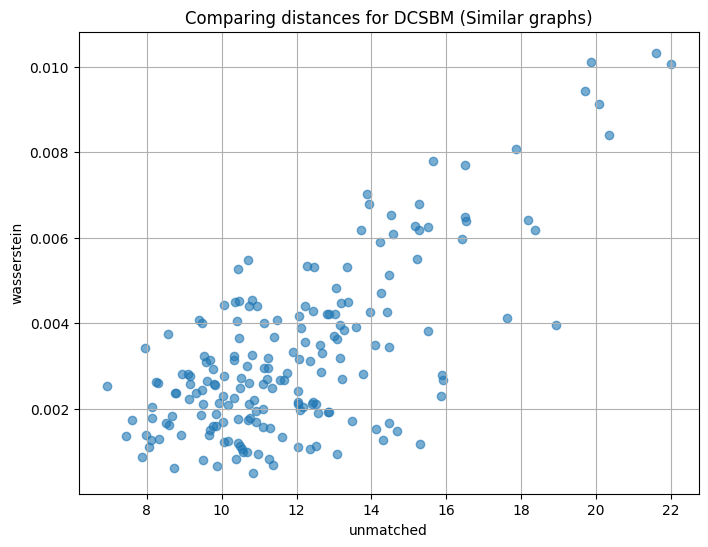

Calcolando distanze:   0%|          | 0/190 [00:00<?, ?it/s]

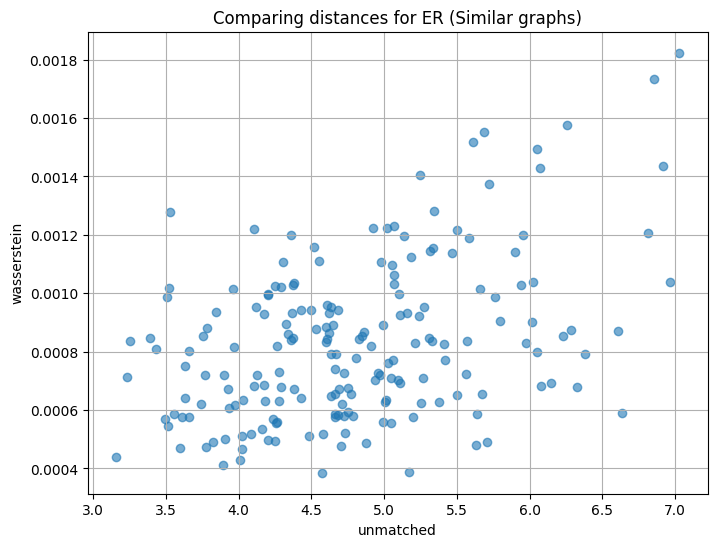

Calcolando distanze:   0%|          | 0/190 [00:00<?, ?it/s]

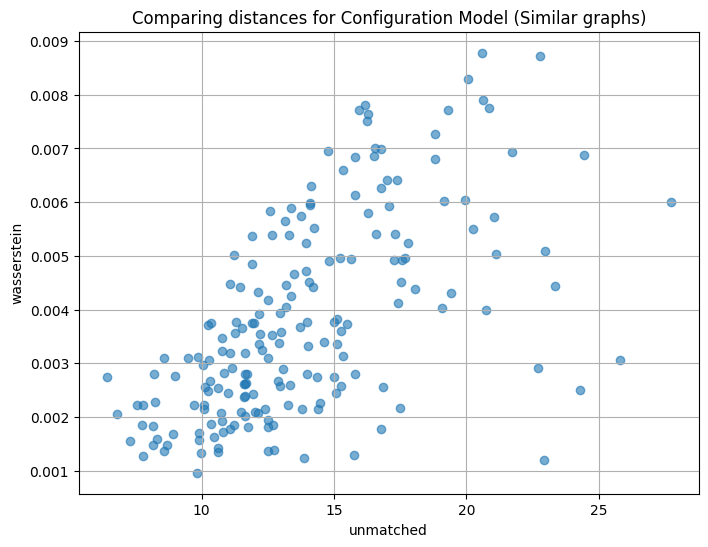

Calcolando distanze:   0%|          | 0/190 [00:00<?, ?it/s]

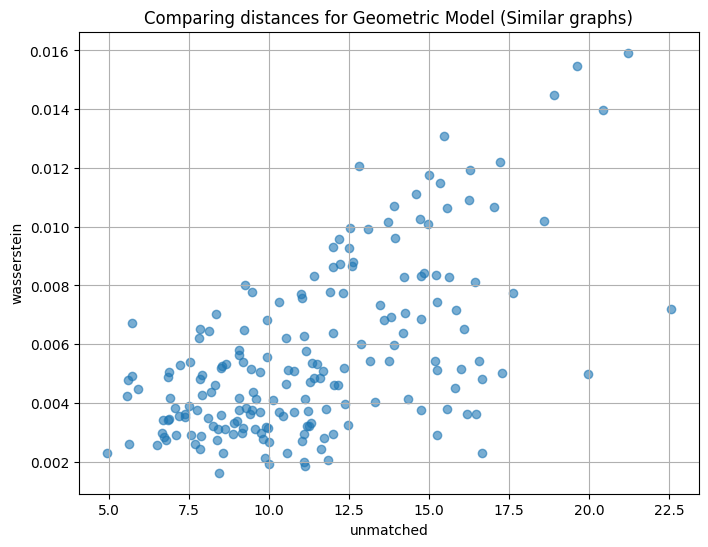

In [99]:
unmatched_old_dcsbm_s, unmatched_new_dcsbm_s = distances(embeddings_dcsbm_s,20)

comparison_plot(unmatched_old_dcsbm_s, unmatched_new_dcsbm_s, 'DCSBM')

unmatched_old_er_s, unmatched_new_er_s = distances(embeddings_er_s,20)

comparison_plot(unmatched_old_er_s, unmatched_new_er_s, 'ER')

unmatched_old_conf_s, unmatched_new_conf_s = distances(embeddings_conf_s,20)

comparison_plot(unmatched_old_conf_s, unmatched_new_conf_s,'Configuration Model')

unmatched_old_geo_s, unmatched_new_geo_s= distances(embeddings_geo_s,20)

comparison_plot(unmatched_old_geo_s, unmatched_new_geo_s, 'Geometric Model')

In [139]:
D_old = squareform(unmatched_old_tot_s)
D_new = squareform(unmatched_new_tot_s)

n_graphs_per_class = 20  
n_classes = 4
 
ℓ = np.concatenate([[i for _ in range(n_graphs_per_class)] for i in range(n_classes)])
k = len(np.unique(ℓ)) 

score_old = NMI(ClusterNMF(D_old, k), ℓ)
score_new = NMI(ClusterNMF(D_new, k), ℓ)

print(f"Unmatched OLD (Unmatched): {score_old:.4f}")
print(f"Unmatched NEW (Wasserstein): {score_new:.4f}")

c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: 

Unmatched OLD (Unmatched): 0.8000
Unmatched NEW (Wasserstein): 0.8143


c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


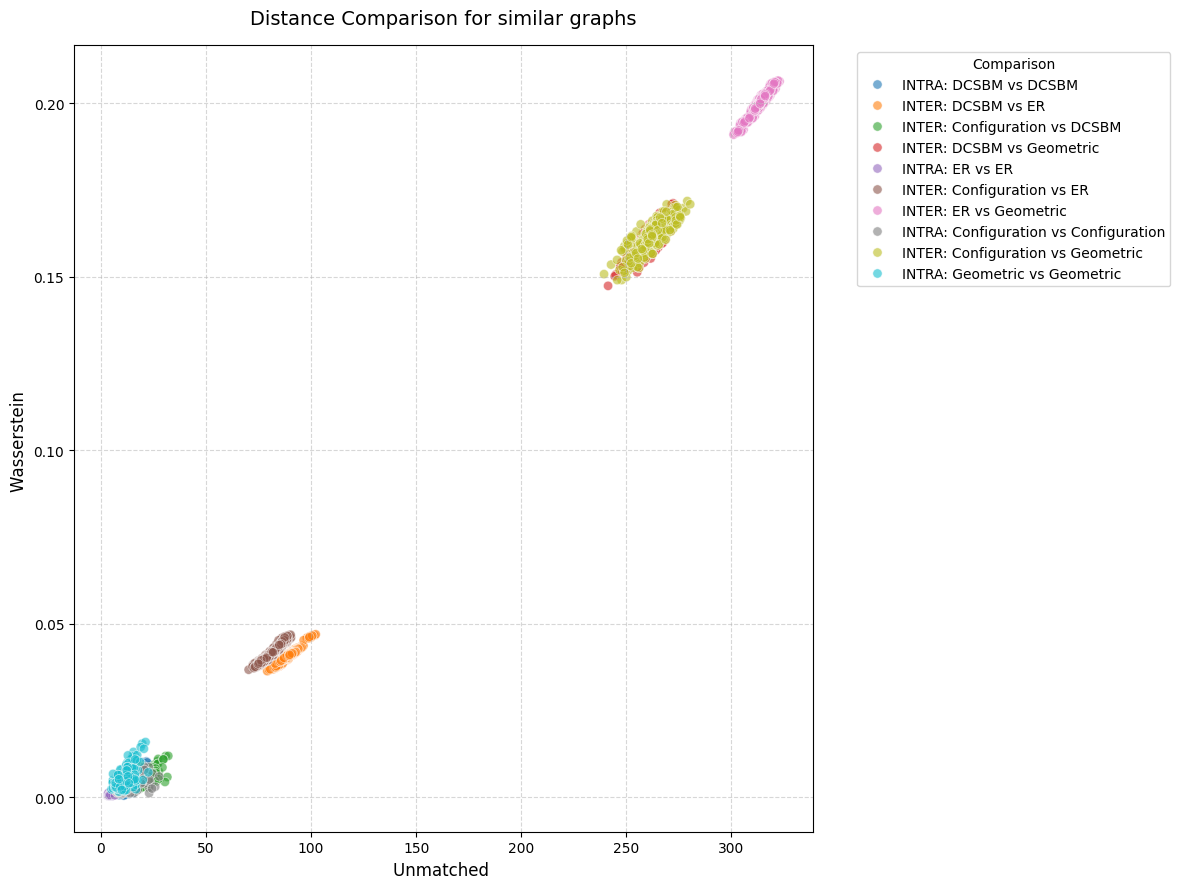

In [101]:
N = 80
labels = [0]*20 + [1]*20 + [2]*20 + [3]*20
models_name = {0: 'DCSBM', 1: 'ER', 2: 'Configuration', 3: 'Geometric'}

categories = []
for i, j in itertools.combinations(range(N), 2):
    mod_i = models_name[labels[i]]
    mod_j = models_name[labels[j]]
    
    if mod_i == mod_j:
        categories.append(f"INTRA: {mod_i} vs {mod_i}")
    else:
        ordered_models = sorted([mod_i, mod_j])
        categories.append(f"INTER: {ordered_models[0]} vs {ordered_models[1]}")

df_plot = pd.DataFrame({
    'Unmatched': unmatched_old_tot_s,
    'Wasserstein': unmatched_new_tot_s,
    'Type': categories
})

plt.figure(figsize=(12, 9)) 

sns.scatterplot(
    data=df_plot,
    x='Unmatched',
    y='Wasserstein',
    hue='Type',
    palette='tab10', 
    alpha=0.6,
    s=45
)
plt.title("Distance Comparison for similar graphs", fontsize=14, pad=15)
plt.xlabel("Unmatched ", fontsize=12)
plt.ylabel("Wasserstein ", fontsize=12)

plt.legend(title="Comparison", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()